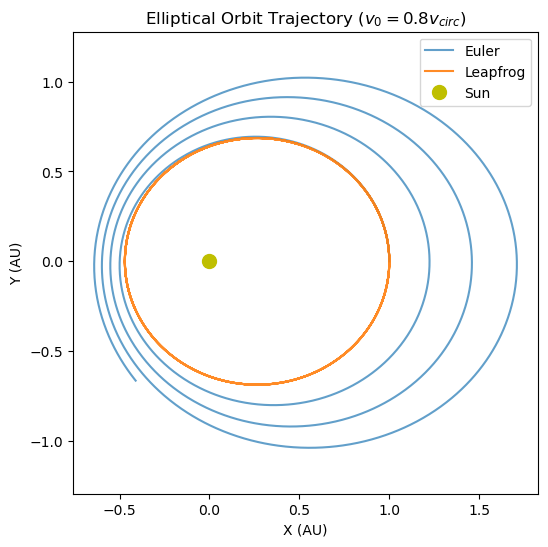

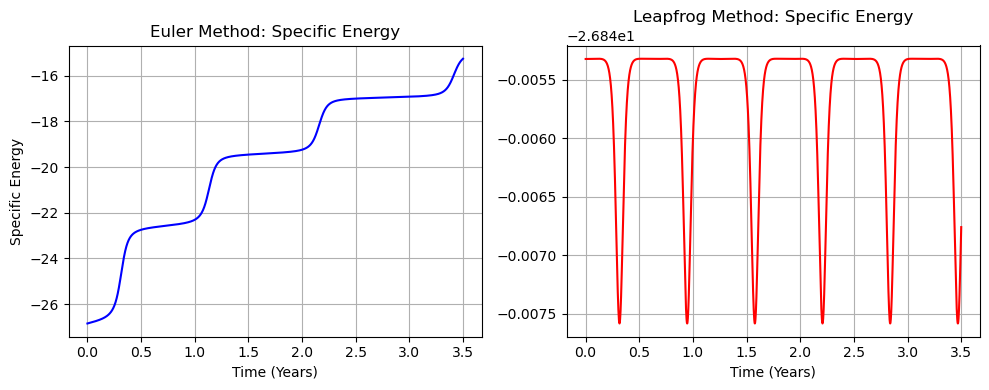

In [1]:
import math
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Setup & Constants
# ---------------------------------------------------------
G = 4 * (math.pi ** 2)
M = 1.0                 
dt = 0.001              
t_max = 3.5             # 3.5 years covers ~5.5 orbits
steps = round(t_max / dt)

# New initial velocity: 0.8 * circular velocity
v0 = 0.8 * (2 * math.pi)

# Starting variables for Euler (x, y, vx, vy)
ex, ey = 1.0, 0.0
evx, evy = 0.0, v0

# Starting variables for Leapfrog (x, y, vx, vy)
lx, ly = 1.0, 0.0
lvx, lvy = 0.0, v0

e_path_x, e_path_y, e_energy = [], [], []
l_path_x, l_path_y, l_energy = [], [], []
time_list = []
current_time = 0.0

# ---------------------------------------------------------
# 2. Integration Loop
# ---------------------------------------------------------
for _ in range(steps):
    time_list.append(current_time)
    
    # --- EULER METHOD ---
    er = math.sqrt(ex**2 + ey**2)
    eax = -(G * M / er**3) * ex
    eay = -(G * M / er**3) * ey
    
    e_path_x.append(ex)
    e_path_y.append(ey)
    e_energy.append(0.5 * (evx**2 + evy**2) - (G * M / er))
    
    ex = ex + evx * dt
    ey = ey + evy * dt
    evx = evx + eax * dt
    evy = evy + eay * dt
    
    # --- LEAPFROG METHOD ---
    lr = math.sqrt(lx**2 + ly**2)
    lax = -(G * M / lr**3) * lx
    lay = -(G * M / lr**3) * ly
    
    l_path_x.append(lx)
    l_path_y.append(ly)
    l_energy.append(0.5 * (lvx**2 + lvy**2) - (G * M / lr))
    
    lvx_half = lvx + lax * (dt / 2.0)
    lvy_half = lvy + lay * (dt / 2.0)
    
    lx = lx + lvx_half * dt
    ly = ly + lvy_half * dt
    
    lr_new = math.sqrt(lx**2 + ly**2)
    lax_new = -(G * M / lr_new**3) * lx
    lay_new = -(G * M / lr_new**3) * ly
    
    lvx = lvx_half + lax_new * (dt / 2.0)
    lvy = lvy_half + lay_new * (dt / 2.0)

    current_time += dt

# ---------------------------------------------------------
# 3. Plotting Results
# ---------------------------------------------------------
# Plot 1: Orbital Trajectory
plt.figure(figsize=(6, 6))
plt.plot(e_path_x, e_path_y, label="Euler", alpha=0.7)
plt.plot(l_path_x, l_path_y, label="Leapfrog", alpha=0.9)
plt.plot(0, 0, 'yo', markersize=10, label="Sun")
plt.title("Elliptical Orbit Trajectory ($v_0 = 0.8 v_{circ}$)")
plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.legend()
plt.axis('equal')

# Plot 2: Specific Energy vs Time
plt.figure(figsize=(10, 4))

# Plot Euler Energy
plt.subplot(1, 2, 1)
plt.plot(time_list, e_energy, 'b-', label="Euler Energy")
plt.title("Euler Method: Specific Energy")
plt.xlabel("Time (Years)")
plt.ylabel("Specific Energy")
plt.grid(True)

# Plot Leapfrog Energy
plt.subplot(1, 2, 2)
plt.plot(time_list, l_energy, 'r-', label="Leapfrog Energy")
plt.title("Leapfrog Method: Specific Energy")
plt.xlabel("Time (Years)")
plt.grid(True)

plt.tight_layout()
plt.show()

The specific energy plot for the Euler method shows severe, repeating spikes (stair-stepping) where the system rapidly gains energy, causing the trajectory plot to show violent orbital precession and an outward spiral.
The Leapfrog energy plot is not a perfectly flat line like it was for the circular orbit. Instead, it shows a distinct oscillating wave pattern that perfectly matches the orbital period.